<a href="https://colab.research.google.com/github/NathanG2022/ml/blob/main/Quant_BiWeekly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [ ]:
events = [
    {
        "id": 1,
        "name": "9/11 Twin\nTower Attacks",
        "short": "9/11",
        "event_date": "2001-09-11",
        "start": "2001-09-07",
        "end":   "2001-12-11",
    },
    {
        "id": 2,
        "name": "Paris Terrorist\nAttacks",
        "short": "Paris",
        "event_date": "2015-11-13",
        "start": "2015-11-09",
        "end":   "2016-02-13",
    },
    {
        "id": 3,
        "name": "Russia Invades\nUkraine (Crimea)",
        "short": "Russia/Ukraine",
        "event_date": "2014-02-22",
        "start": "2014-02-18",
        "end":   "2014-05-22",
    },
    {
        "id": 4,
        "name": "Saudi Aramco\nDrone Attack",
        "short": "Drones",
        "event_date": "2019-09-14",
        "start": "2019-09-10",
        "end":   "2019-12-14",
    },
    {
        "id": 5,
        "name": "US Kills\nGeneral Soleimani",
        "short": "Soleimani ",
        "event_date": "2020-01-03",
        "start": "2019-12-30",
        "end":   "2020-03-03",
    },
    {
        "id": 6,
        "name": "Hamas Surprise\nAttack on Israel",
        "short": "Hamas",
        "event_date": "2023-10-07",
        "start": "2023-10-03",
        "end":   "2024-01-07",
    },
]

In [ ]:
sectors = {
    "Defense": {
        "tickers": ["LMT", "RTX", "NOC", "GD",  "LHX"],
        "names":   ["Lockheed Martin", "RTX/RTN", "Northrop Grumman",
                    "General Dynamics", "L3Harris/LLL"],
        "colors":  ["#003f5c", "#374c80", "#7a5195", "#bc5090", "#ef5675"],
        "etf":     "ITA",
        "etf_name": "ITA ETF",
    },
    "Energy": {
        "tickers": ["XOM", "CVX", "COP", "SHEL", "BP"],
        "names":   ["Exxon", "Chevron", "ConocoPhillips", "Shell", "BP"],
        "colors":  ["#ffa600", "#ff764a", "#ef5675", "#bc5090", "#7a5195"],
        "etf":     "XLE",
        "etf_name": "XLE ETF",
    },
    "Tourism": {
        "tickers": ["BKNG", "EXPE", "MAR", "HLT", "TCOM", "DAL"],
        "names":   ["Booking Holdings", "Expedia", "Marriott", "Hilton", "Trip.com", "Delta"],
        "colors":  ["#00b4d8", "#0096c7", "#0077b6", "#023e8a", "#03045e"],
        "etf":     "TRVL",
        "etf_name": "Travel ETF",
    },
}

In [ ]:
LEGACY_TICKERS = ["RTN", "LLL"]
ETF_TICKERS    = ["ITA", "XLE", "AWAY"]

all_download = list(set(
    [t for s in sectors.values() for t in s["tickers"]]
    + LEGACY_TICKERS
    + ETF_TICKERS
))

In [ ]:
def resolve_ticker(ticker, event_date_str):
    """Return correct historical ticker for a given event date, or None if pre-IPO."""
    event_date = pd.Timestamp(event_date_str)
    if ticker not in LEGACY_TICKERS:
        return ticker
    for (old_ticker, cutoff_str) in LEGACY_TICKERS[ticker]:
        if event_date < pd.Timestamp(cutoff_str):
            return old_ticker
    return ticker

In [ ]:
print("Downloading price data (2001–2024) ...")
raw = yf.download(
    all_download,
    start="2001-09-01",
    end="2024-01-31",
    auto_adjust=True,
    progress=True,
)["Close"]

[*********************100%***********************]  21 of 21 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['LLL', 'RTN']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
print(f"Done — {raw.shape[0]} trading days\n")

Done — 5636 trading days



In [ ]:
def pct_from_event(df, event_date_str, start_str, end_str):
    """
    Slice [start, end] from df and return % change relative to the first
    available close ON OR AFTER event_date.  Returns (pct_df, base_date).
    """
    start      = pd.Timestamp(start_str)
    end        = pd.Timestamp(end_str)
    event_date = pd.Timestamp(event_date_str)

    window     = df.loc[start:end].copy()
    after_evt  = window.index[window.index >= event_date]
    if after_evt.empty:
        return None, None

    base_date  = after_evt[0]
    base       = window.loc[base_date]
    pct        = (window / base - 1) * 100
    return pct, base_date


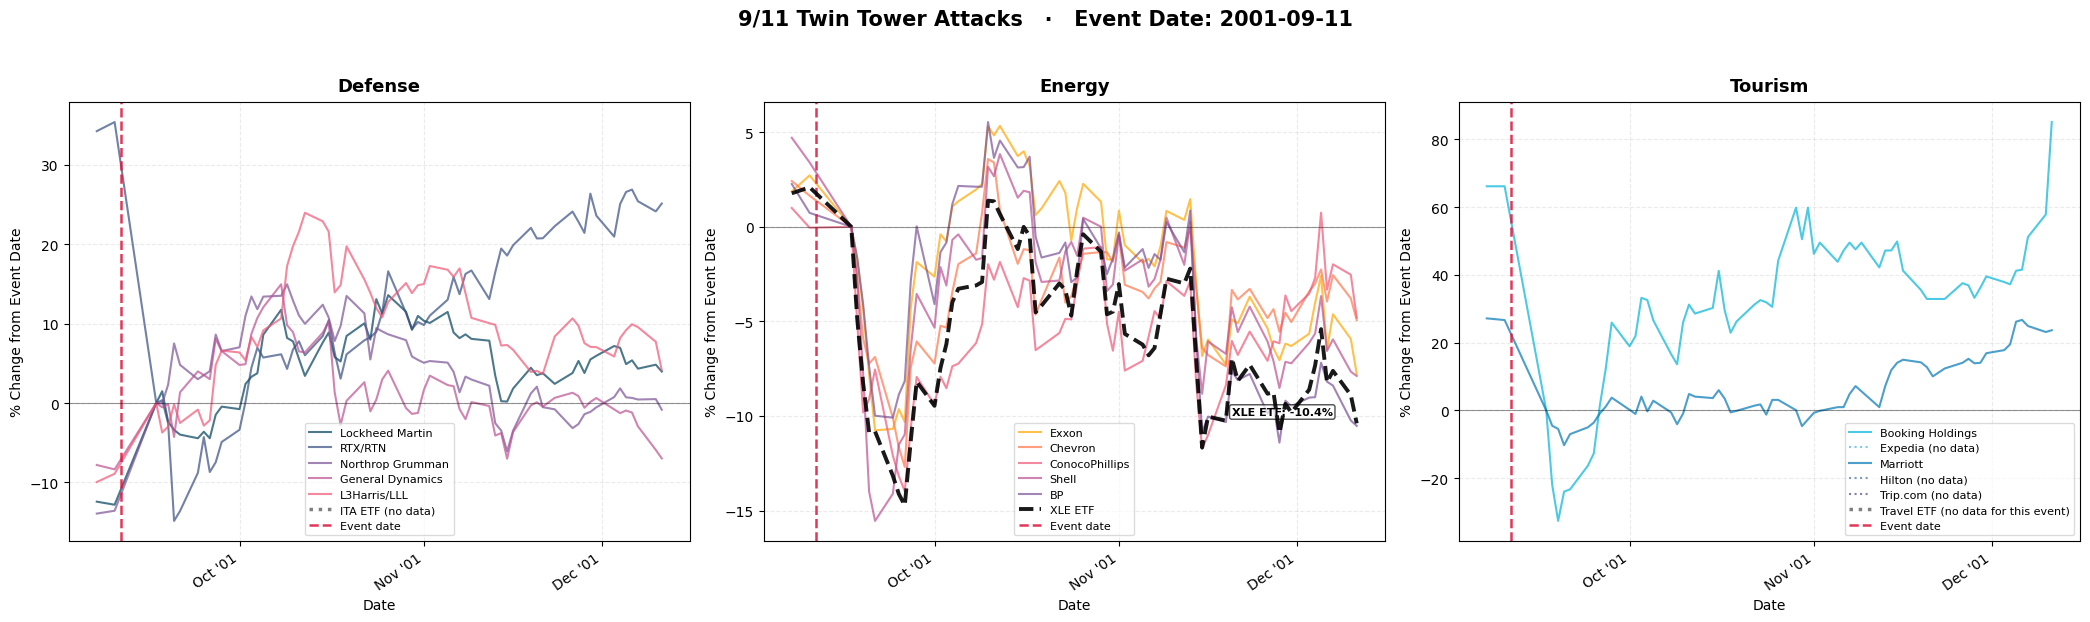

Event 1 saved → event_1_9-11.png


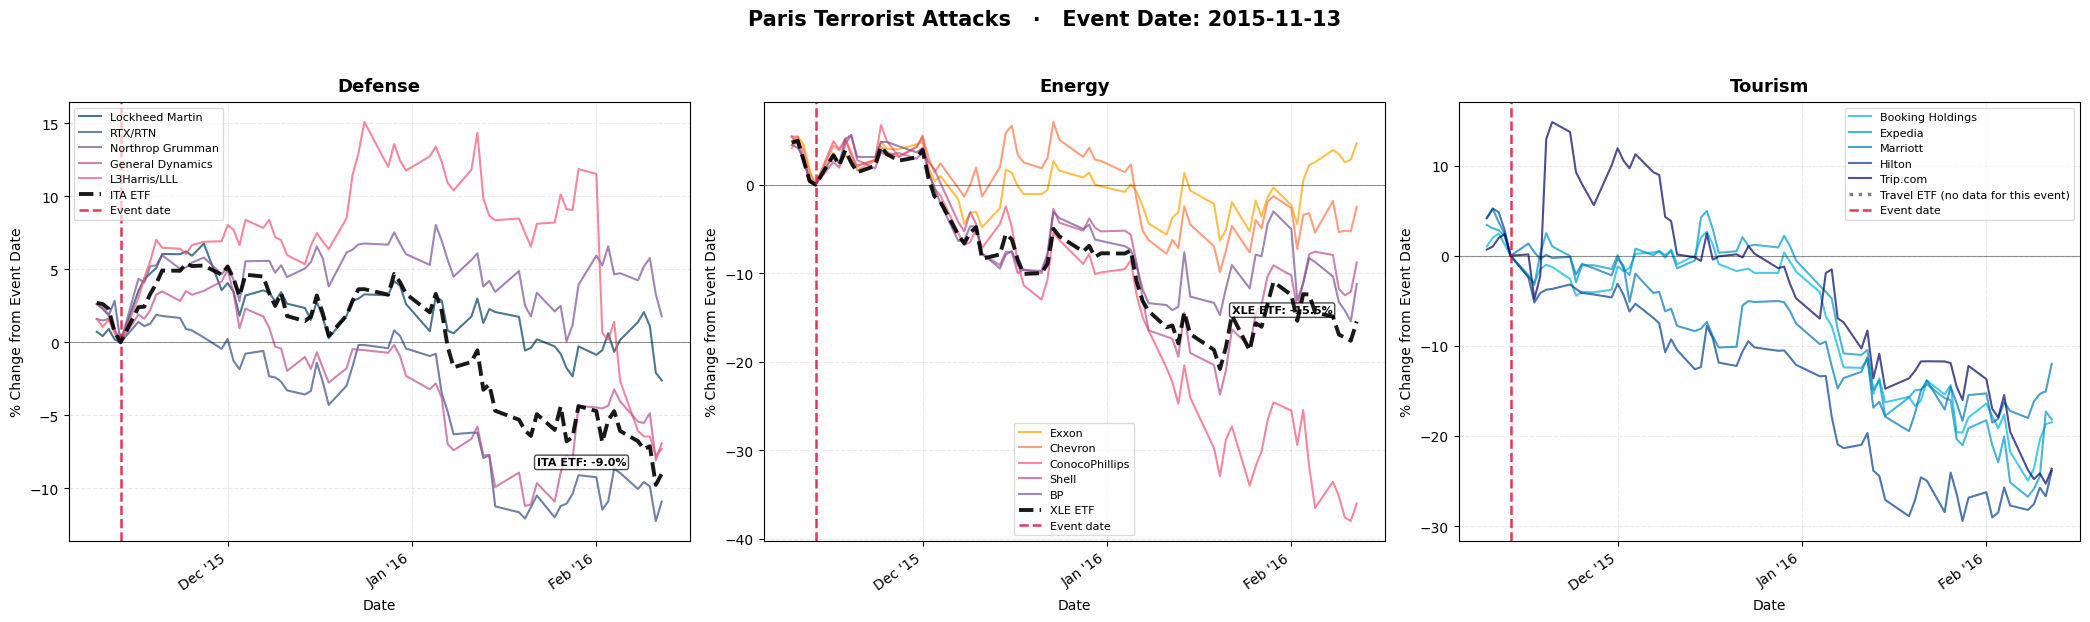

Event 2 saved → event_2_Paris.png


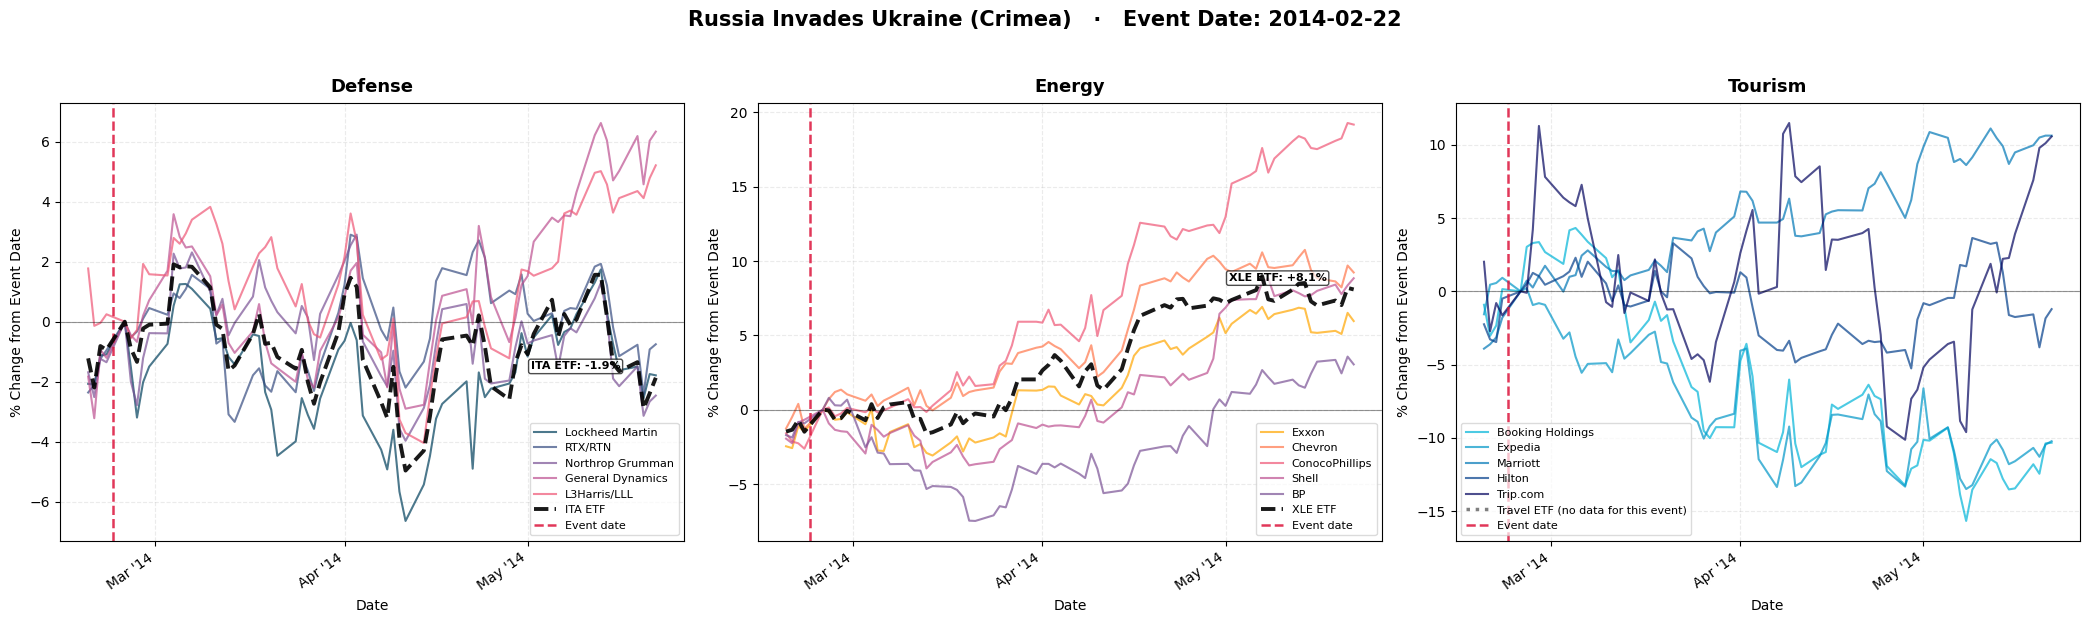

Event 3 saved → event_3_Russia-Ukraine.png


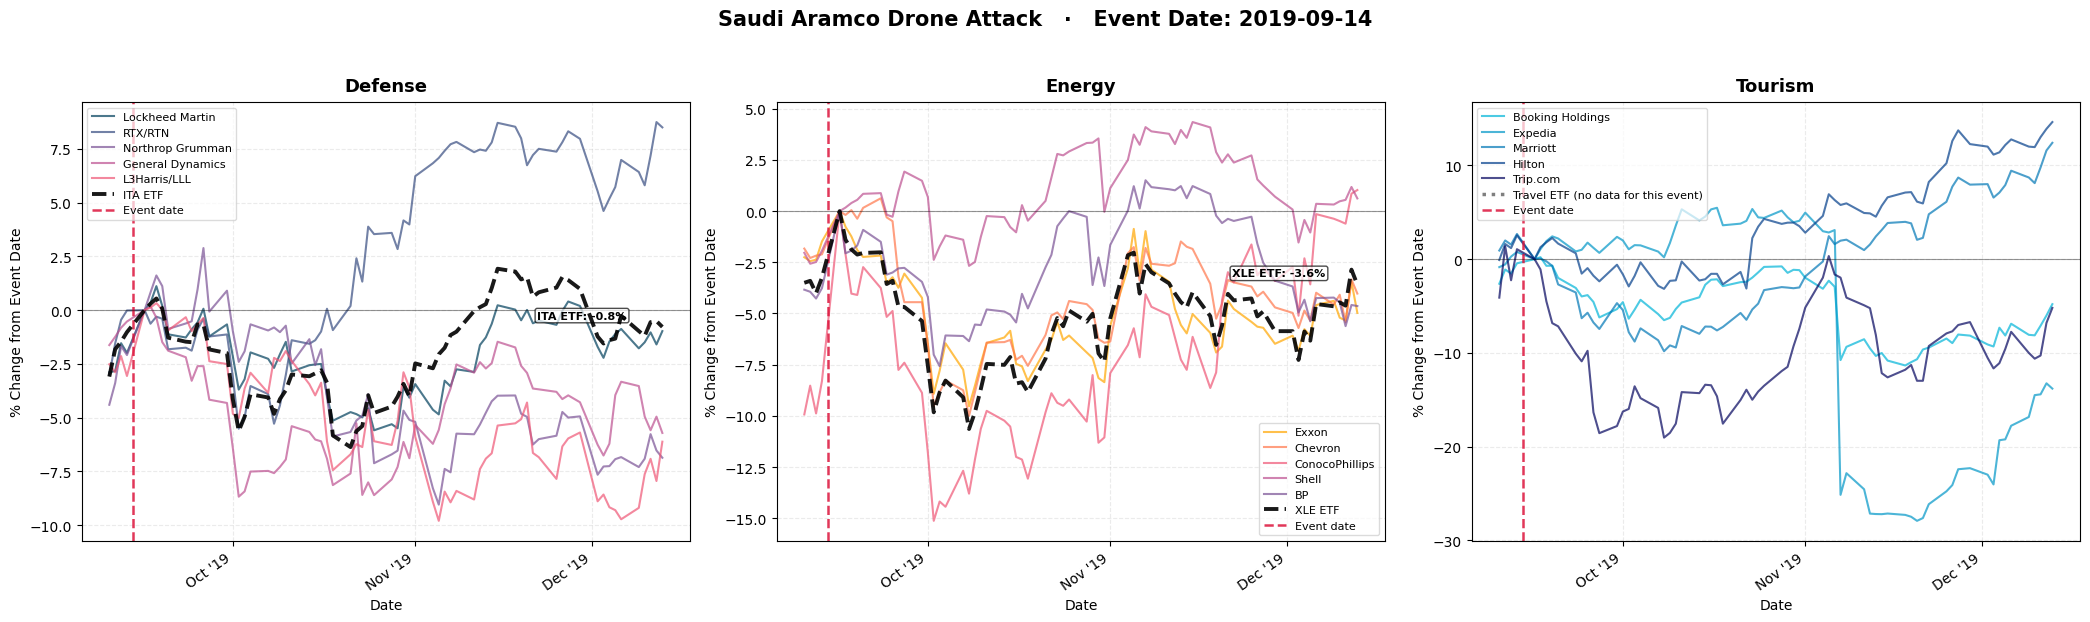

Event 4 saved → event_4_Drones.png


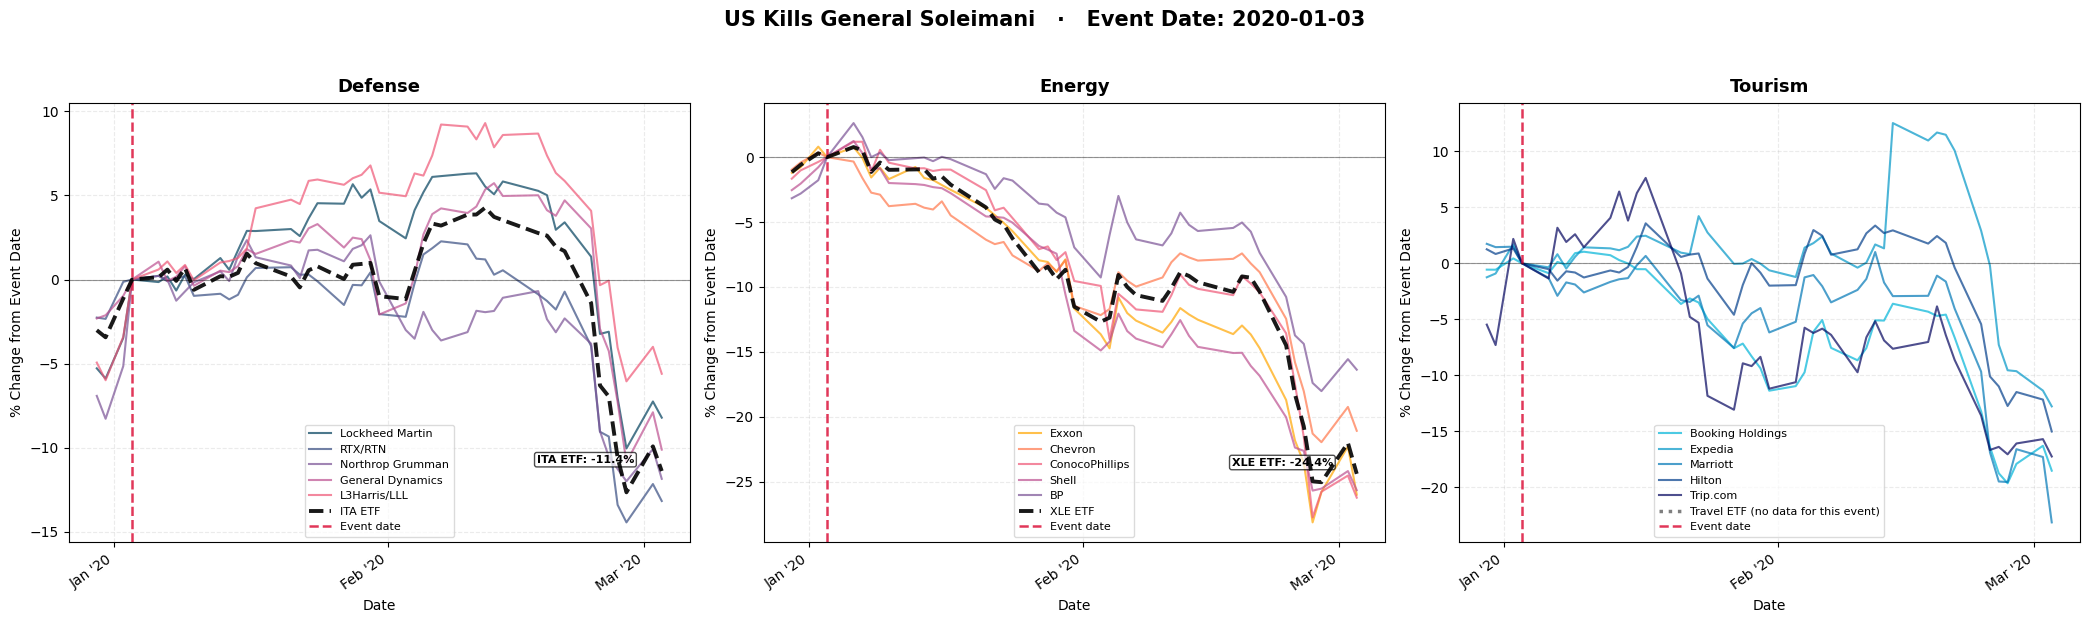

Event 5 saved → event_5_Soleimani_.png


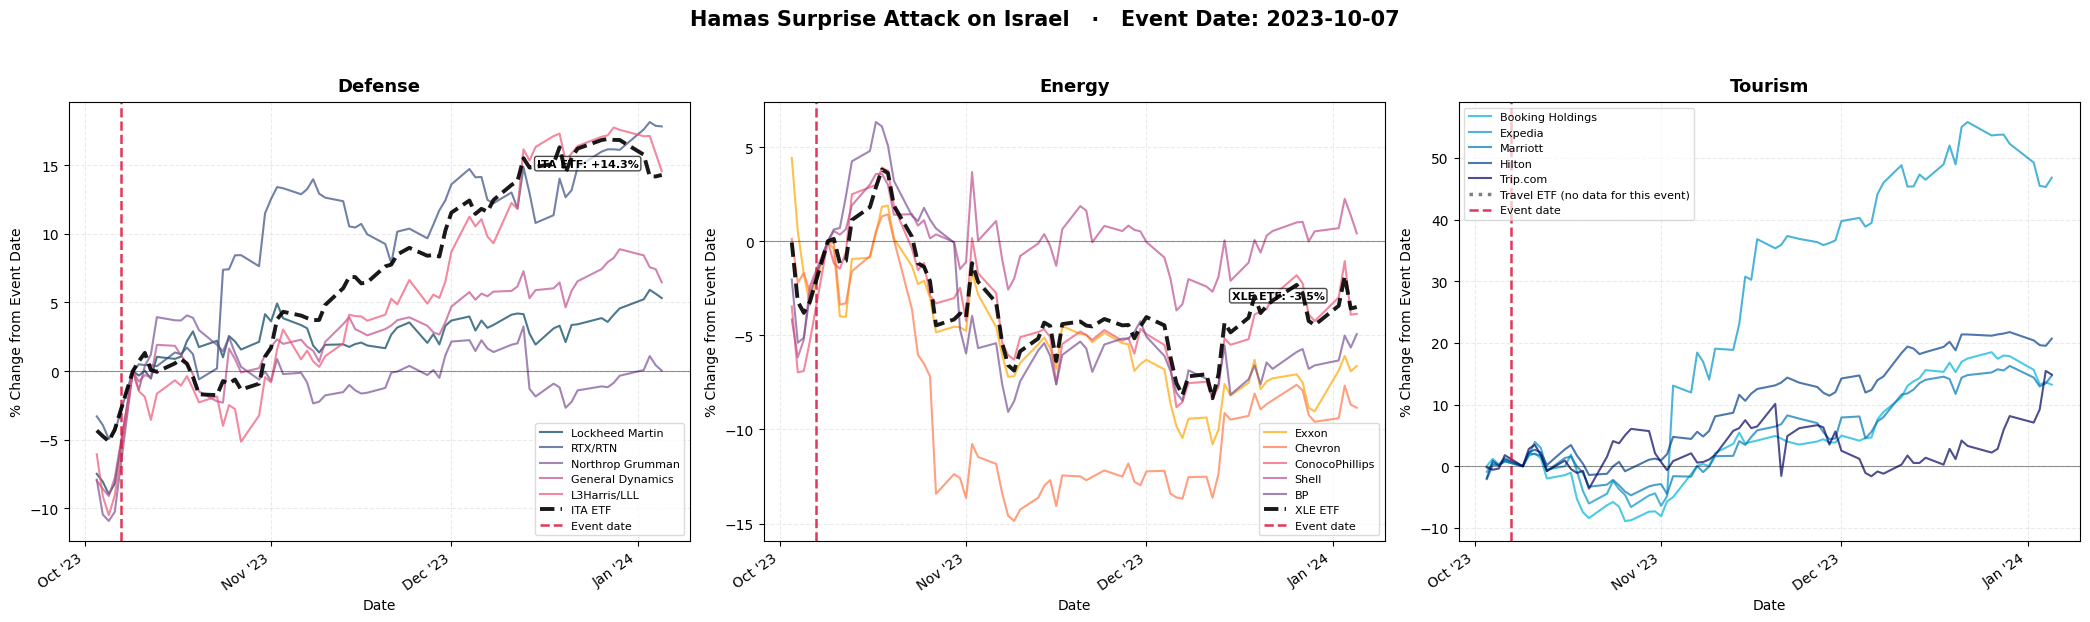

Event 6 saved → event_6_Hamas.png


In [ ]:
summary_rows = []

for ev in events:
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.suptitle(
        f"{ev['name'].replace(chr(10), ' ')}   ·   Event Date: {ev['event_date']}",
        fontsize=15, fontweight="bold", y=1.03,
    )

    for ax, (sector_name, sinfo) in zip(axes, sectors.items()):
        tickers  = sinfo["tickers"]
        names    = sinfo["names"]
        colors   = sinfo["colors"]
        etf      = sinfo["etf"]
        etf_name = sinfo["etf_name"]

        # ── Individual stocks ─────────────────────────────────────────────────
        cols_available = [t for t in tickers if t in raw.columns]
        if not cols_available:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", fontsize=12)
            ax.set_title(sector_name, fontsize=13, fontweight="bold")
            continue

        pct_df, base_date = pct_from_event(
            raw[cols_available], ev["event_date"], ev["start"], ev["end"]
        )
        if pct_df is None:
            ax.text(0.5, 0.5, "No data in window", ha="center", va="center", fontsize=12)
            ax.set_title(sector_name, fontsize=13, fontweight="bold")
            continue

        for ticker, name, color in zip(tickers, names, colors):
            resolved = resolve_ticker(ticker, ev["event_date"])

            if resolved is None:
                ax.plot([], [], label=f"{name} (no data)", color=color,
                        linewidth=1.5, linestyle=":", alpha=0.5)
                continue

            if resolved not in pct_df.columns:
                continue

            s = pct_df[resolved].dropna()
            if s.empty:
                ax.plot([], [], label=f"{name} (no data)", color=color,
                        linewidth=1.5, linestyle=":", alpha=0.5)
                continue

            ax.plot(s.index, s.values, label=name, color=color,
                    linewidth=1.5, alpha=0.7)

            summary_rows.append({
                "event":   ev["short"],
                "sector":  sector_name,
                "ticker":  ticker,
                "name":    name,
                "end_pct": round(s.iloc[-1], 2),
            })

        # ── ETF overlay ───────────────────────────────────────────────────────
        if etf in raw.columns:
            etf_pct, _ = pct_from_event(
                raw[[etf]], ev["event_date"], ev["start"], ev["end"]
            )
            if etf_pct is not None:
                etf_series = etf_pct[etf].dropna()
                if not etf_series.empty:
                    ax.plot(
                        etf_series.index,
                        etf_series.values,
                        label=etf_name,
                        color="black",
                        linewidth=2.8,
                        linestyle="--",
                        alpha=0.9,
                        zorder=5,        # draw on top of individual stocks
                    )
                    # Annotate ETF final value
                    ax.annotate(
                        f"{etf_name}: {etf_series.iloc[-1]:+.1f}%",
                        xy=(etf_series.index[-1], etf_series.iloc[-1]),
                        xytext=(-90, 6),
                        textcoords="offset points",
                        fontsize=8,
                        fontweight="bold",
                        color="black",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
                    )
                else:
                    ax.plot([], [], label=f"{etf_name} (no data)", color="black",
                            linewidth=2.5, linestyle=":", alpha=0.5)
        else:
            ax.plot([], [], label=f"{etf_name} (no data for this event)",
                    color="black", linewidth=2.5, linestyle=":", alpha=0.5)

        # ── Annotations ───────────────────────────────────────────────────────
        event_ts = pd.Timestamp(ev["event_date"])
        ax.axvline(event_ts, color="crimson", linestyle="--", linewidth=1.8,
                   alpha=0.85, label="Event date")
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)

        ax.set_title(sector_name, fontsize=13, fontweight="bold", pad=8)
        ax.set_xlabel("Date", fontsize=10)
        ax.set_ylabel("% Change from Event Date", fontsize=10)
        ax.legend(fontsize=8, framealpha=0.7, loc="best")
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha="right")

    plt.tight_layout()
    fname = f"event_{ev['id']}_{ev['short'].replace('/', '-').replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Event {ev['id']} saved → {fname}")

In [ ]:
def get_sector_avg_normalized(sector_info, ev):
    """
    Returns a pd.Series indexed by trading-day offset (0, 1, 2, ...)
    where 0 = first trading day on/after event_date.
    """
    tickers = sector_info["tickers"]
    names   = sector_info["names"]

    start      = pd.Timestamp(ev["start"])
    end        = pd.Timestamp(ev["end"])
    event_date = pd.Timestamp(ev["event_date"])

    stock_series = []

    for ticker, name in zip(tickers, names):
        resolved = resolve_ticker(ticker, ev["event_date"])
        if resolved is None or resolved not in raw.columns:
            continue

        window = raw[resolved].loc[start:end].dropna()
        after  = window.index[window.index >= event_date]
        if after.empty:
            continue

        base = window.loc[after[0]]
        if base == 0:
            continue

        pct = (window / base - 1) * 100

        # Reindex to trading-day offset from event (day 0 = event date)
        pct_from_event = pct.loc[after[0]:]
        pct_from_event.index = range(len(pct_from_event))  # 0, 1, 2, ...
        stock_series.append(pct_from_event)

    if not stock_series:
        return None

    combined = pd.concat(stock_series, axis=1)
    return combined.mean(axis=1)


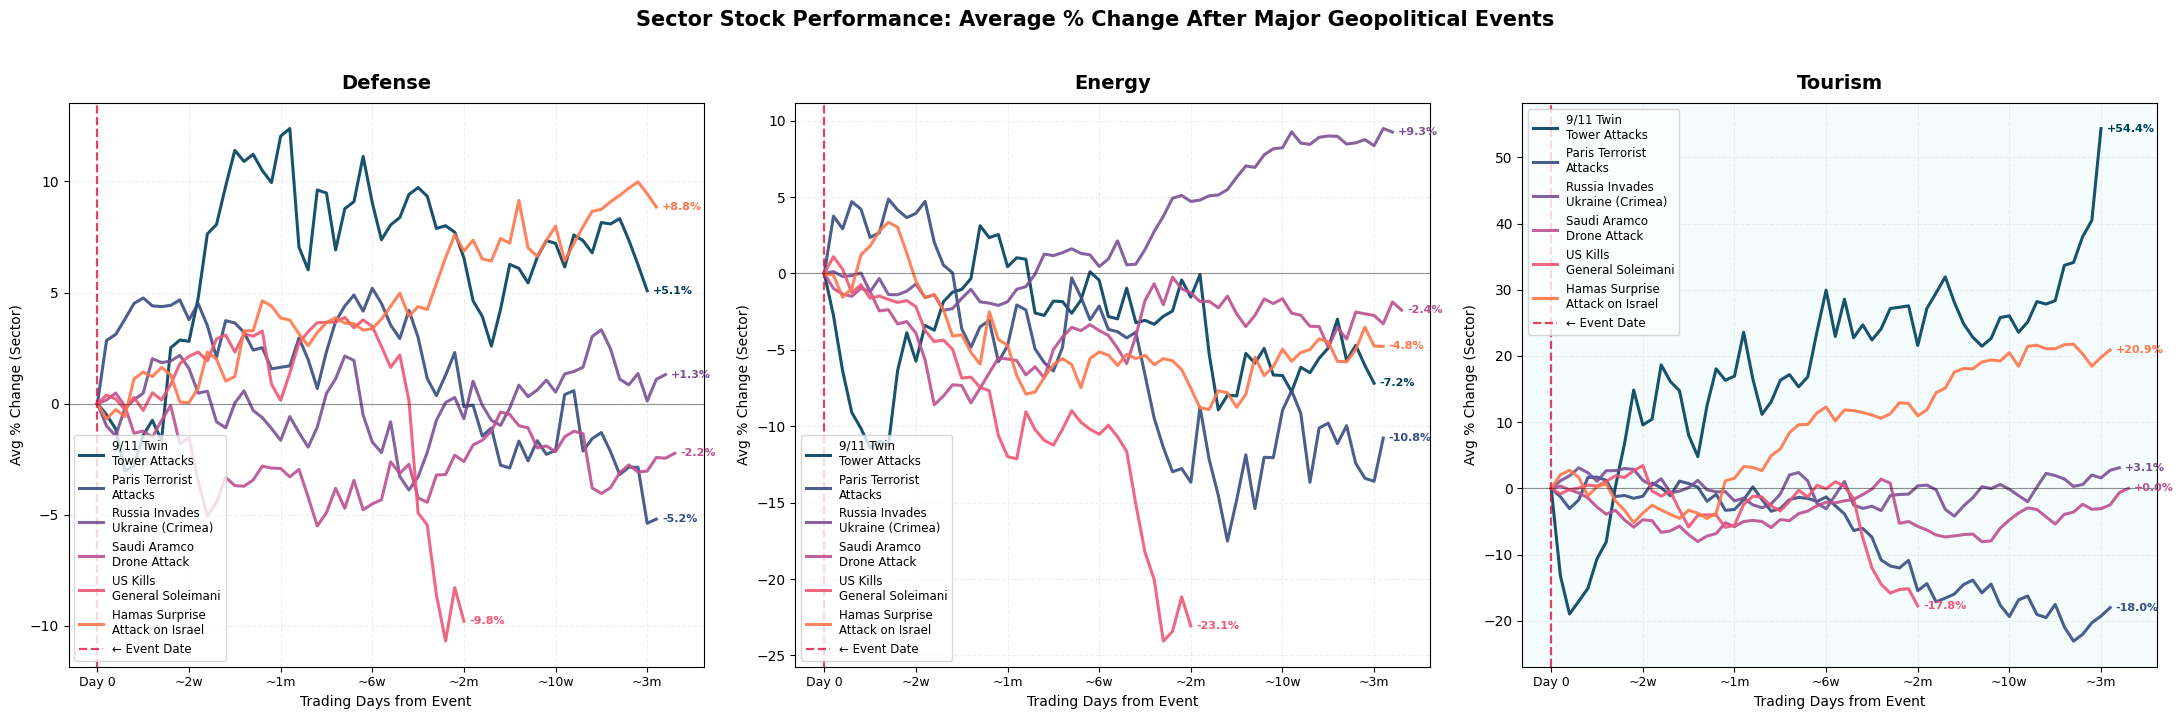

Saved → sector_event_comparison.png


In [ ]:
EVENT_COLORS = [
    "#003f5c", "#374c80", "#7a5195",
    "#bc5090", "#ef5675", "#ff764a",
]
EVENT_STYLES = ["-", "-", "-", "-", "-", "-"]

# ── Plot: one figure per sector ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "Sector Stock Performance: Average % Change After Major Geopolitical Events",
    fontsize=15, fontweight="bold", y=1.02,
)
for ax, (sector_name, sinfo) in zip(axes, sectors.items()):
    sector_color = sinfo["colors"]

    for ev, ev_color, ev_style in zip(events, EVENT_COLORS, EVENT_STYLES):
        avg = get_sector_avg_normalized(sinfo, ev)
        if avg is None or avg.empty:
            continue

        ax.plot(
            avg.index,
            avg.values,
            label=ev["name"],
            color=ev_color,
            linewidth=2.2,
            linestyle=ev_style,
            alpha=0.9,
        )

        # Annotate final value at end of line
        ax.annotate(
            f"{avg.iloc[-1]:+.1f}%",
            xy=(avg.index[-1], avg.iloc[-1]),
            xytext=(4, 0),
            textcoords="offset points",
            fontsize=8,
            color=ev_color,
            fontweight="bold",
            va="center",
        )

    # ── Zero line & event marker ──────────────────────────────────────────────
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1.6,
               alpha=0.8, label="← Event Date")
    ax.axhline(0, color="black",   linewidth=0.8, alpha=0.4)

    # ── x-axis: trading days → approximate calendar weeks label ──────────────
    max_days = 65
    tick_positions = [0, 10, 20, 30, 40, 50, 60]
    tick_labels    = ["Day 0", "~2w", "~1m", "~6w", "~2m", "~10w", "~3m"]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)

    ax.set_title(sector_name, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Trading Days from Event", fontsize=10)
    ax.set_ylabel("Avg % Change (Sector)", fontsize=10)
    ax.legend(fontsize=8.5, framealpha=0.8, loc="best")
    ax.grid(True, alpha=0.2, linestyle="--")

    # Light shading behind the sector color to differentiate panels
ax.set_facecolor((*plt.matplotlib.colors.to_rgb(sector_color[0]), 0.04))

plt.tight_layout()
plt.savefig("sector_event_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sector_event_comparison.png")